In [ ]:
from datetime import datetime
from getpass import getpass
import random

rdm_url = 'https://develop.rdm.example.com/'
idp_name_1 = "GakuNin RDM IdP"
idp_username_1 = "user_test01"
idp_password_1 = "password_test01"
name_user_admin = 'name_user_test_admin'
name_user_1 = 'name_user_test01'
name_user_2 = 'name_user_test02'
name_user_3 = 'name_user_test03'
name_user_4 = 'name_user_test04'
name_user_5 = 'name_user_test05'
group_A = "Test_Sougou_GroupA"
group_C = "Sougou_Test_GroupC"
group_B = "Sougou_Test_GroupB"
group_D = "Sougou_Test_GroupD"
rdm_project_name = 'TEST-グループ管理連携機能検証-{}'.format(datetime.now().strftime('%Y%m%d'))
target_storage_name = 'NII Storage'
target_storage_id = 'osfstorage'
delete_project = True
default_result_path = None
close_on_fail = False
transition_timeout = 60000
group_note_text = '※本機能はムーンショット目標2'
component_title = "コンポーネント"

In [2]:
if idp_username_1 is None:
    idp_username_1 = input(prompt=f'Username for {idp_name_1}')
if idp_password_1 is None:
    idp_password_1 = getpass(prompt=f'Password for {idp_username_1}@{idp_name_1}')
(len(idp_username_1), len(idp_password_1))

(7, 16)

In [4]:
import tempfile

work_dir = tempfile.mkdtemp()
if default_result_path is None:
    default_result_path = work_dir
work_dir

'/tmp/tmpyt34j8h7'

# プロジェクトに対するグループ機能②

- サブシステム名: グループ管理連携機能
- ページ/アドオン: プロジェクトに対するグループ機能
- 機能分類: プロジェクトに対するグループ機能②
- シナリオ名: 削除
- 用意するテストデータ: アカウント(既存ユーザー1,2,3,4,5),再利用可能(条件なし)

In [5]:
import importlib
import pandas as pd

import scripts.playwright
importlib.reload(scripts.playwright)

from scripts.playwright import *
from scripts import grdm

await init_pw_context(close_on_fail=close_on_fail, last_path=default_result_path)

('20260330-042358', '/tmp/tmpx16wjd6t')

## ウェブブラウザの新規プライベートウィンドウで GRDM トップページを表示する

- GRDM トップページが表示されること

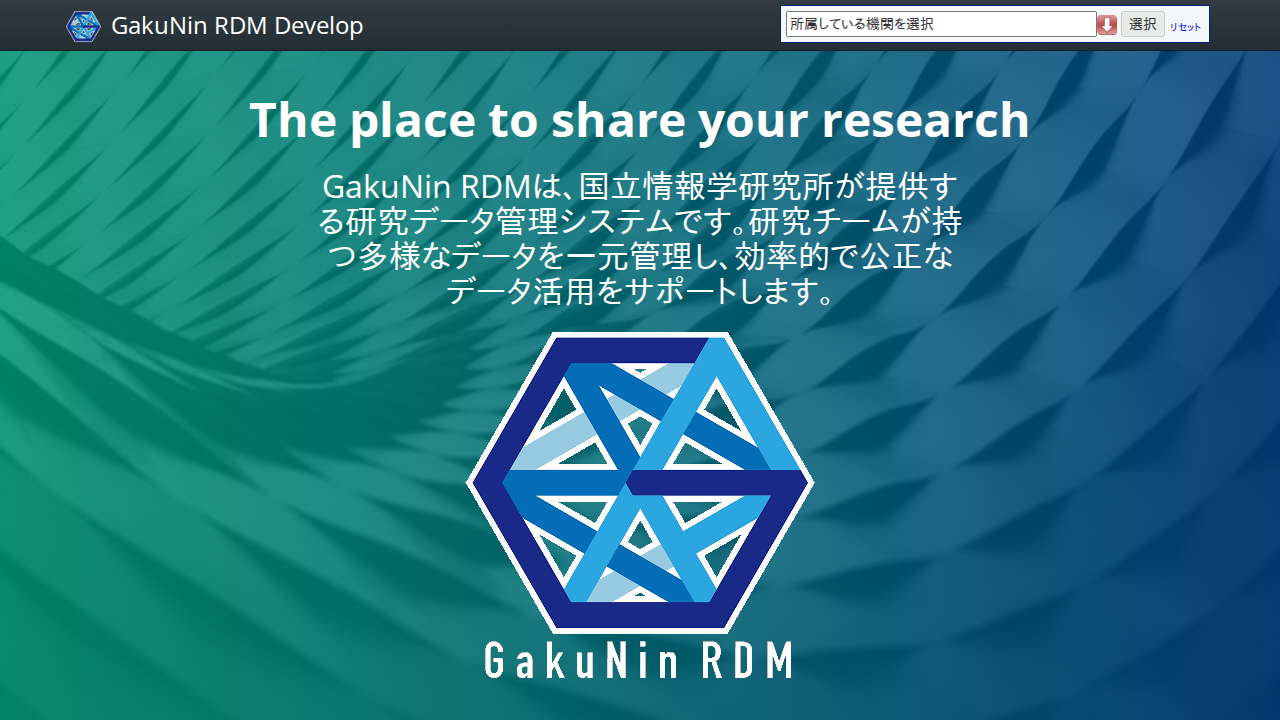

In [6]:
import scripts.grdm
importlib.reload(scripts.grdm)

async def _step(page):
    await page.goto(rdm_url)

    # 同意する をクリック
    await page.locator('//button[text() = "同意する"]').click()

    # 同意する が表示されなくなったことを確認
    await expect(page.locator('//button[text() = "同意する"]')).to_have_count(0, timeout=500)

await run_pw(_step)

## RDMIdPを利用し、既存ユーザー1としてログインする

- GRDM ダッシュボードが表示されること

In [ ]:
async def _step(page):

    await grdm.login(page, idp_name_1, idp_username_1, idp_password_1, transition_timeout=transition_timeout)

    # GRDMのボタンが表示されることを確認
    await expect(page.get_by_text("プロジェクト管理者")).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## ダッシュボードから「プロジェクトに対するグループ機能①」シートのNo.4で作成したプロジェクトをクリックする

- プロジェクトダッシュボードが表示されること
- プロジェクトダッシュボードの上部メニューに「ファイル」、「Wiki」、「メタデータ」、「エクスポート」、「メンバ」、「グループ」、「アドオン」、「設定」「証跡管理」が表示されること(「管理者」権限)
- プロジェクトダッシュボードの画面右部の「コンポーネント」の「{コンポーネント名}」の下に、以下のメンバ/グループが表示されること
    - 機関管理者1
    - 既存ユーザー1 
    - 既存ユーザー2 
    - 既存ユーザー3
    - 既存ユーザー2 が所属するグループ(グループA)
    - 既存ユーザー3 が所属するグループ(グループB)
    - 既存ユーザー4 が所属するグループ(グループC)
    - 既存ユーザー5 が所属するグループ(グループD)

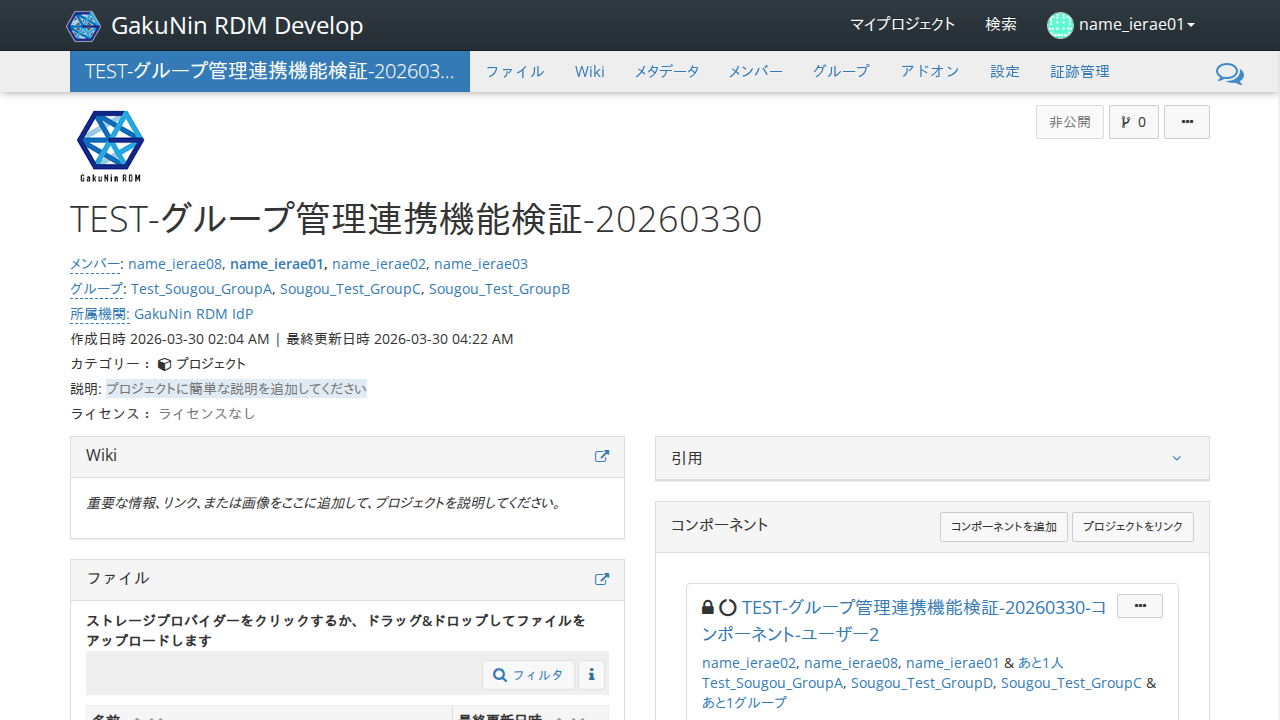

In [ ]:
async def _step(page):
    await page.locator(f'//*[@data-test-dashboard-item-title and text()="{rdm_project_name}"]').click()

    await expect(page.locator("#projectSubnav").get_by_role("link", name="ファイル")).to_be_visible(timeout=transition_timeout)
    await expect(page.locator("#projectSubnav").get_by_role("link", name="Wiki")).to_be_visible(timeout=transition_timeout)
    await expect(page.locator("#projectSubnav").get_by_role("link", name="メタデータ")).to_be_visible(timeout=transition_timeout)
    await expect(page.locator("#projectSubnav").get_by_role("link", name="メンバー")).to_be_visible(timeout=transition_timeout)
    await expect(page.locator("#projectSubnav").get_by_role("link", name="グループ", exact=True)).to_be_visible(timeout=transition_timeout)
    await expect(page.locator("#projectSubnav").get_by_role("link", name="アドオン")).to_be_visible(timeout=transition_timeout)
    await expect(page.locator("#projectSubnav").get_by_role("link", name="設定")).to_be_visible(timeout=transition_timeout)
    await expect(page.locator("#projectSubnav").get_by_role("link", name="証跡管理")).to_be_visible(timeout=transition_timeout)
    await expect(grdm.get_select_expanded_storage_title_locator(page, target_storage_name)).to_be_visible(timeout=transition_timeout)
    time.sleep(1)

    # Wait for components widget to be visible
    components_section = page.locator("span#components, .render-nodes-list, div:has-text('コンポーネント')")
    await expect(components_section.first).to_be_visible(timeout=transition_timeout)
    
    # Verify component exists by checking for any component item
    component_item = components_section.locator("li.list-group-item-node").first
    await expect(component_item).to_be_visible(timeout=transition_timeout)
    
    # Verify component title contains part of the expected text
    component_title = component_item.locator("h4.list-group-item-heading a").first
    await expect(component_title).to_be_visible(timeout=transition_timeout)
    
    # Verify the title contains expected keywords
    title_text = await component_title.text_content()
    assert "コンポーネント" in title_text, f"Expected 'コンポーネント' in title, but got: {title_text}"
    
    # Verify users
    user_block = component_item.locator(".project-authors").nth(0)
    user_links = user_block.locator("a.overflow")
    # Visible users (max 3)
    visible_users = await user_links.all_text_contents()
    expected_users = {name_user_admin, name_user_1, name_user_2, name_user_3}
    for user in visible_users:
        assert user in expected_users
    # Hidden users exist
    await expect(user_block.get_by_text("あと1人")).to_be_visible()

    # Verify groups
    group_block = component_item.locator(".project-authors").nth(1)
    group_links = group_block.locator("a.overflow")
    # Visible groups
    visible_group_texts = await group_links.all_text_contents()
    expected_groups = {group_A, group_B, group_C, group_D, 'あと1グループ'}
    for group in visible_group_texts:
        assert group in expected_groups
    # Hidden groups exist
    # await expect(group_block.get_by_text("あと1グループ")).to_be_visible()

await run_pw(_step)

## プロジェクトダッシュボードの画面右部の「コンポーネント」の「{コンポーネント名}」をクリックする

- コンポーネントのプロジェクトダッシュボードが表示されること

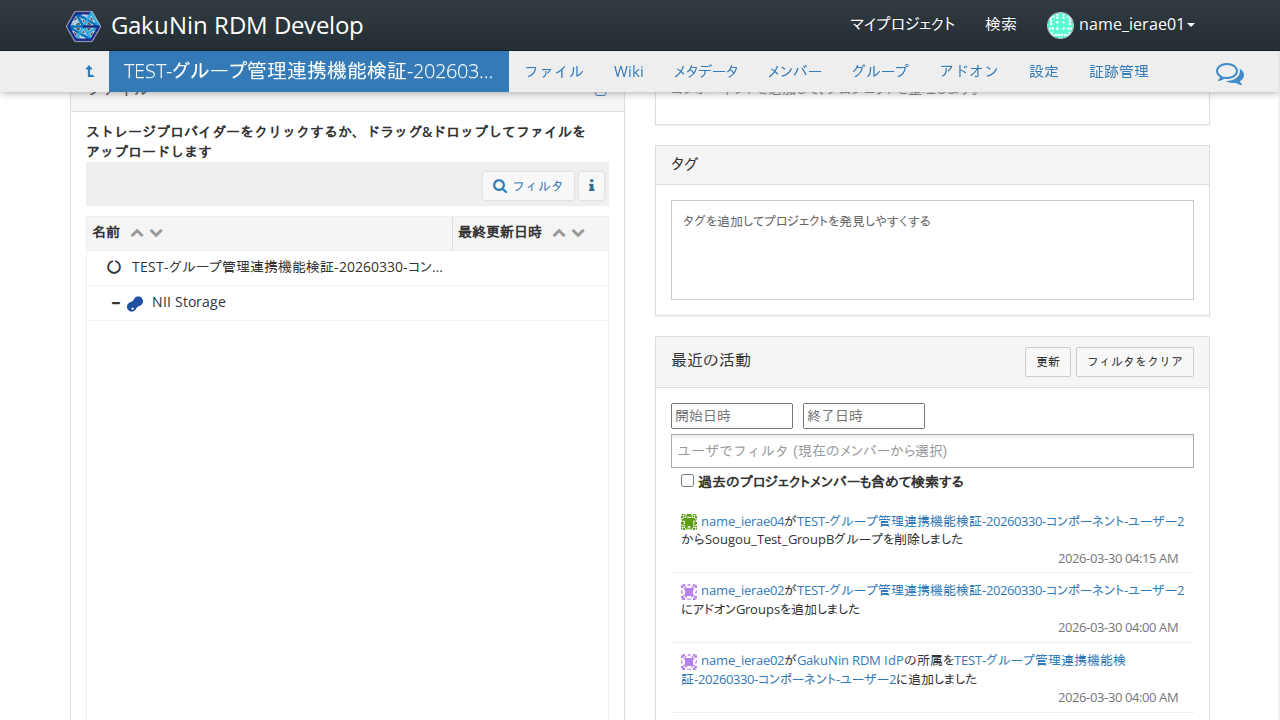

In [9]:
async def _step(page):

    await page.locator('a.fg-file-links', has_text='コンポーネント').click()

    await expect(page.locator('//a[text() = "アドオン"]')).to_be_visible(timeout=transition_timeout)
    await expect(grdm.get_select_expanded_storage_title_locator(page, target_storage_name)).to_be_visible(timeout=transition_timeout)

    await page.locator('//h3[text()="最近の活動"]').click()

await run_pw(_step)

## コンポーネントのプロジェクトダッシュボードの上部メニューから「グループ」をクリックする

- 「グループ」画面が表示されること
- 各グループが以下の通りとなっていること。
    - 既存ユーザー2 が所属するグループ(グループA): 読込み/書込み
    - 既存ユーザー3 が所属するグループ(グループB): 読込み
    - 既存ユーザー4 が所属するグループ(グループC): 管理者
    - 既存ユーザー5 が所属するグループ(グループD): 読込み"

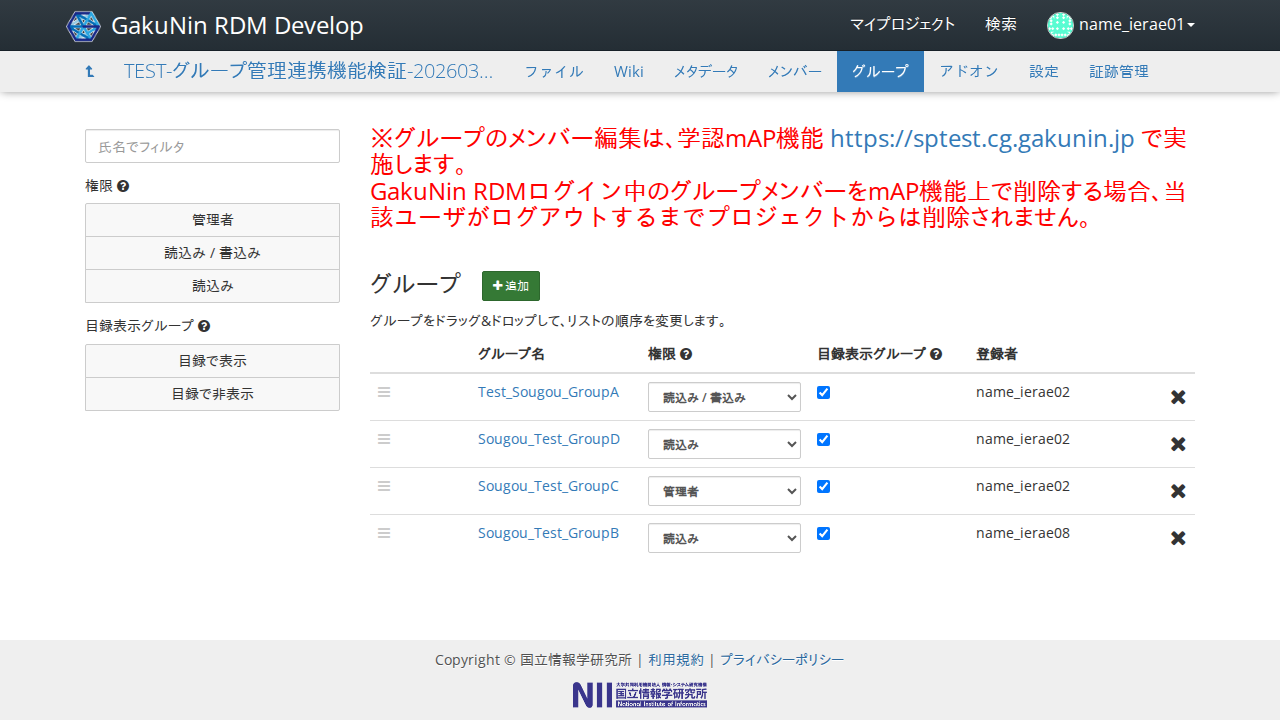

In [ ]:
async def _step(page):
    
    # Access グループ screen
    await page.locator("#projectSubnav").get_by_role("link", name="グループ", exact=True).click()

    # グループ screen is displayed
    await expect(page.get_by_role("heading", name=group_note_text)).to_be_visible(timeout=transition_timeout)

    # Groups permission
    Groups = {group_A: "読込み / 書込み", group_B: "読込み", group_C: "管理者", group_D: "読込み",}

    groups_tbody = page.locator("#groups")

    for group_name, expected_permission in Groups.items():
        row = groups_tbody.locator("tr").filter(has=page.get_by_text(group_name, exact=True))
        await expect(row).to_have_count(1)
        permission = row.locator(".permission-filter")
        await expect(permission).to_have_text(expected_permission)

await run_pw(_step)

## 「名前」項目の既存ユーザー2が所属するグループ(グループA)の列の右端の「×」ボタンをクリックする

- 「グループを削除」ダイアログが表示されること

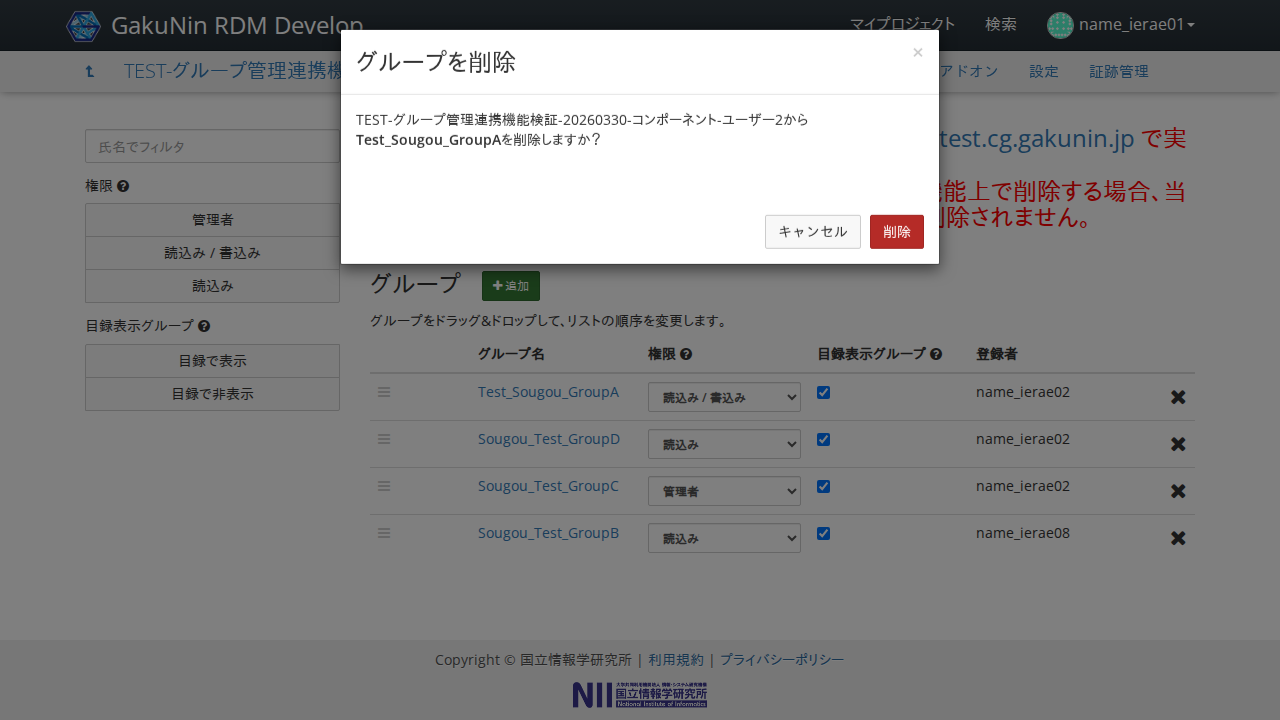

In [12]:
async def _step(page):
    
    # Identify group A
    group_row = page.locator("#groups tr").filter(has=page.get_by_text(group_A, exact=True))
    
    # Click the "remove (×)" button
    remove_button = group_row.locator("td.add-remove i.remove-or-reject")
    time.sleep(1)
    await remove_button.click() 
    await expect(page.locator("h3.modal-title", has_text="グループを削除")).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「グループを削除」ダイアログの「削除」ボタンをクリックする

- 「グループ」画面が表示されること
- 各グループが以下の通りとなっていること。
    - 既存ユーザー3 が所属するグループ(グループB): 読込み
    - 既存ユーザー4 が所属するグループ(グループC): 管理者
    - 既存ユーザー5 が所属するグループ(グループD): 読込み

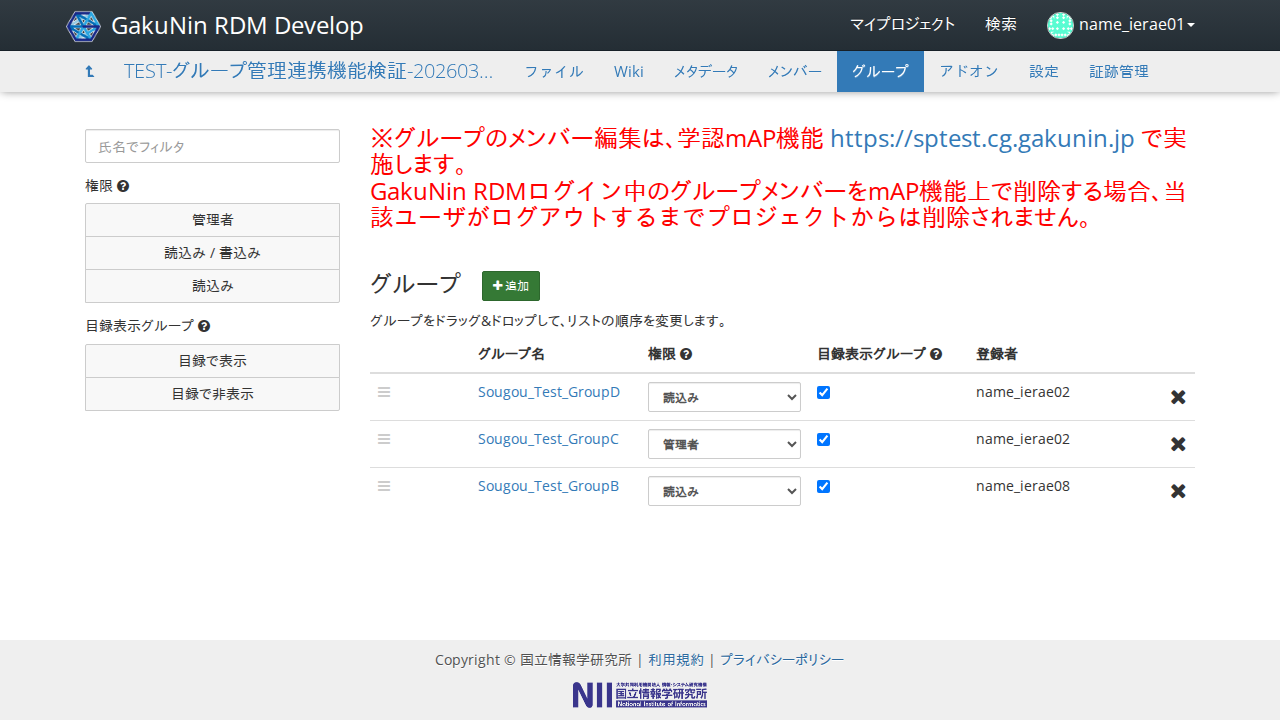

In [ ]:
async def _step(page):

    # Ensure modal exists
    delete_modal = page.locator("div.modal-content.scripted", has=page.locator("h3.modal-title", has_text="グループを削除"))
    await expect(delete_modal).to_be_attached()

    # Click 削除 button
    delete_button = delete_modal.locator("div.remove-page-buttons a.btn.btn-danger")
    await delete_button.click()

    # Wait until modal is removed
    await expect(delete_modal).not_to_be_attached()
    
    # グループ screen is displayed
    await expect(page.get_by_role("heading", name=group_note_text)).to_be_visible(timeout=transition_timeout)
    
    # Groups are displayed
    groups = [(group_B, "読込み"),(group_C, "管理者"),(group_D, "読込み"),]
    for group_name, permission in groups:
        group_row = page.locator("#manageGroupsTable tbody tr.contrib", has=page.locator("a.name-search", has_text=group_name))
        await expect(group_row).to_be_visible()
        # Permission
        permission_locator = group_row.locator(".permission-filter") 
        await expect(permission_locator).to_have_text(permission)

await run_pw(_step)

## 「名前」項目の既存ユーザー3が所属するグループ(グループB)の列の右端の「×」ボタンをクリックする

- 「グループを削除」ダイアログが表示されること

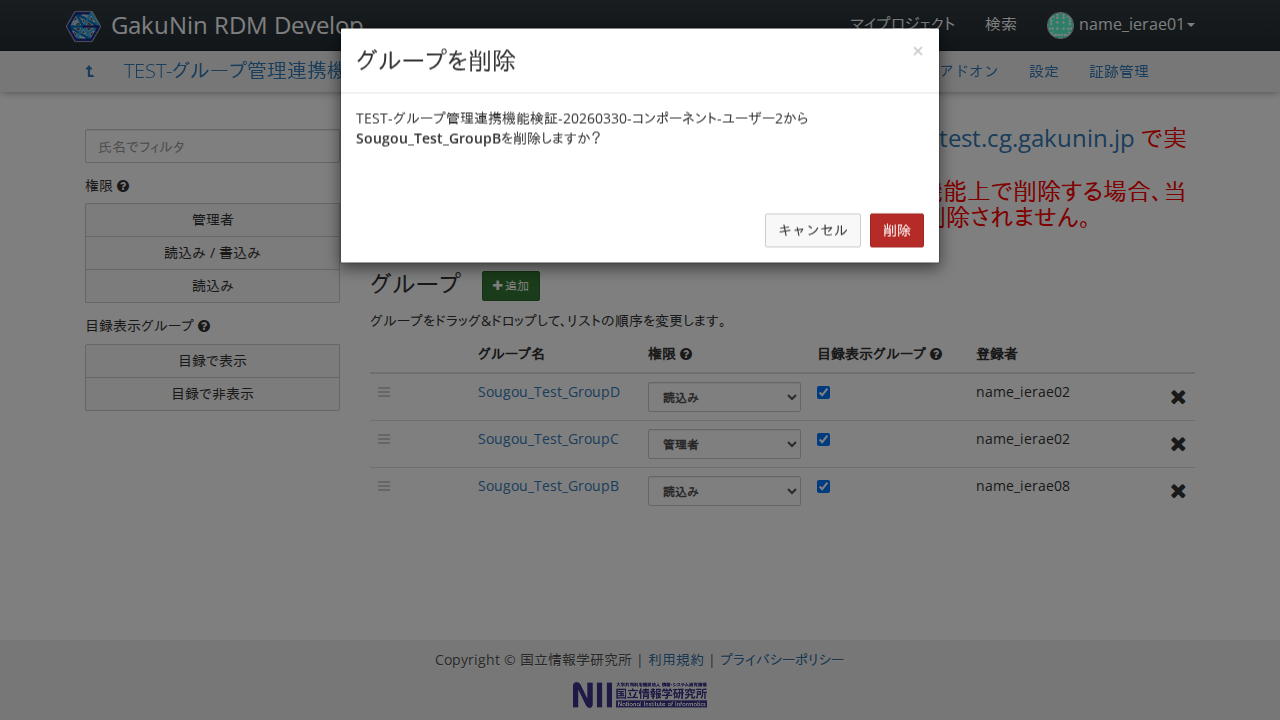

In [14]:
async def _step(page):
    
    # Identify group B
    group_row = page.locator("#groups tr").filter(has=page.get_by_text(group_B, exact=True))
    
    # Click the "remove (×)" button
    remove_button = group_row.locator("td.add-remove i.remove-or-reject")
    time.sleep(1)
    await remove_button.click() 
    await expect(page.locator("h3.modal-title", has_text="グループを削除")).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「グループを削除」ダイアログの「削除」ボタンをクリックする

- 「グループ」画面が表示されること
- 各グループが以下の通りとなっていること。
    - 既存ユーザー4 が所属するグループ(グループC): 管理者
    - 既存ユーザー5 が所属するグループ(グループD): 読込み"

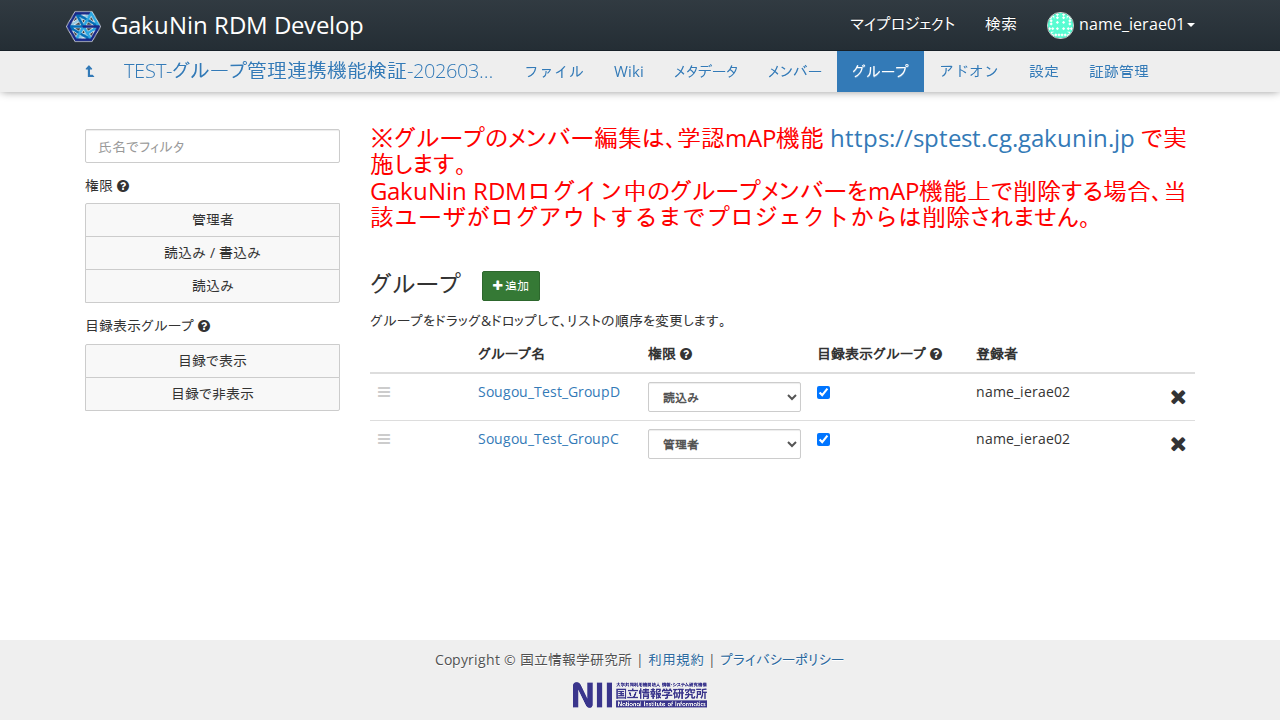

In [ ]:
async def _step(page):

    # Ensure modal exists
    delete_modal = page.locator("div.modal-content.scripted", has=page.locator("h3.modal-title", has_text="グループを削除"))
    await expect(delete_modal).to_be_attached()

    # Click 削除 button
    delete_button = delete_modal.locator("div.remove-page-buttons a.btn.btn-danger")
    await delete_button.click()

    # Wait until modal is removed
    await expect(delete_modal).not_to_be_attached()
    
    # グループ screen is displayed
    await expect(page.get_by_role("heading", name=group_note_text)).to_be_visible(timeout=transition_timeout)
    
    # Groups are displayed
    groups = [(group_C, "管理者"),(group_D, "読込み"),]
    for group_name, permission in groups:
        group_row = page.locator("#manageGroupsTable tbody tr.contrib", has=page.locator("a.name-search", has_text=group_name))
        await expect(group_row).to_be_visible()
        # Permission
        permission_locator = group_row.locator(".permission-filter") 
        await expect(permission_locator).to_have_text(permission)
        
await run_pw(_step)

## 「名前」項目の既存ユーザー4が所属するグループ(グループC)の列の右端の「×」ボタンをクリックする

- 「グループを削除」ダイアログが表示されること

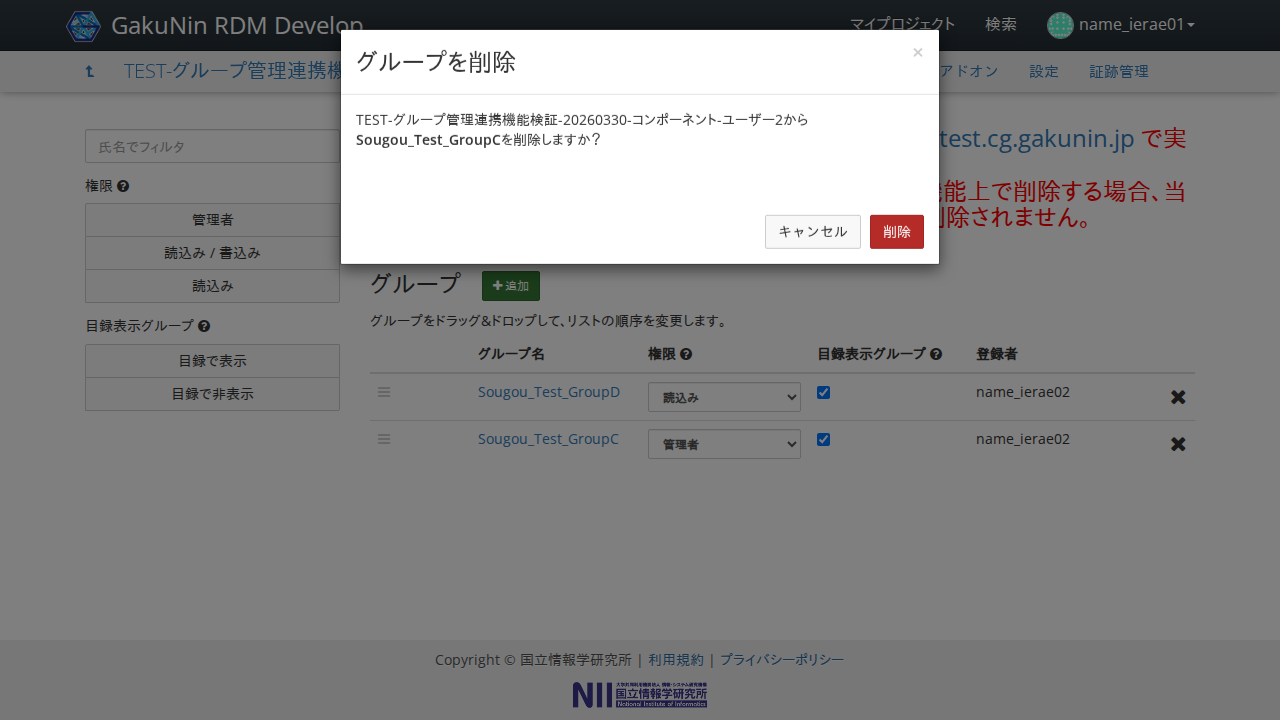

In [16]:
async def _step(page):
    
    # Identify group C
    group_row = page.locator("#groups tr").filter(has=page.get_by_text(group_C, exact=True))
    
    # Click the "remove (×)" button
    remove_button = group_row.locator("td.add-remove i.remove-or-reject")
    time.sleep(1)
    await remove_button.click() 
    await expect(page.locator("h3.modal-title", has_text="グループを削除")).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「グループを削除」ダイアログの「削除」ボタンをクリックする

- 「グループ」画面が表示されること
- 各グループが以下の通りとなっていること。
    - 既存ユーザー5 が所属するグループ(グループD): 読込み

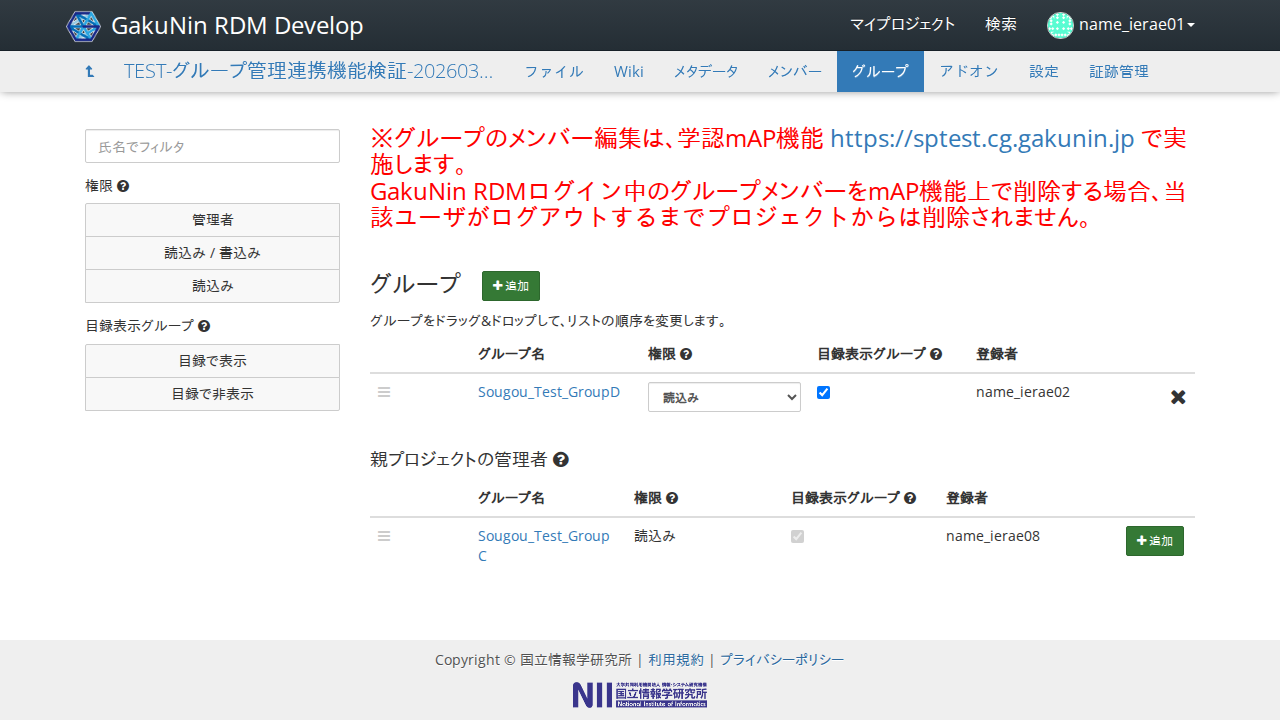

In [ ]:
async def _step(page):

    # Ensure modal exists
    delete_modal = page.locator("div.modal-content.scripted", has=page.locator("h3.modal-title", has_text="グループを削除"))
    await expect(delete_modal).to_be_attached()

    # Click 削除 button
    delete_button = delete_modal.locator("div.remove-page-buttons a.btn.btn-danger")
    await delete_button.click()

    # Wait until modal is removed
    await expect(delete_modal).not_to_be_attached()
    
    # グループ screen is displayed
    await expect(page.get_by_role("heading", name=group_note_text)).to_be_visible(timeout=transition_timeout)
    
    # Groups are displayed
    groups = [(group_D, "読込み"),]
    for group_name, permission in groups:
        group_row = page.locator("#manageGroupsTable tbody tr.contrib", has=page.locator("a.name-search", has_text=group_name))
        await expect(group_row).to_be_visible()
        # Permission
        permission_locator = group_row.locator(".permission-filter") 
        await expect(permission_locator).to_have_text(permission)
        
await run_pw(_step)

## 「名前」項目の既存ユーザー5が所属するグループ(グループD)の列の右端の「×」ボタンをクリックする	

- 「グループを削除」ダイアログが表示されること

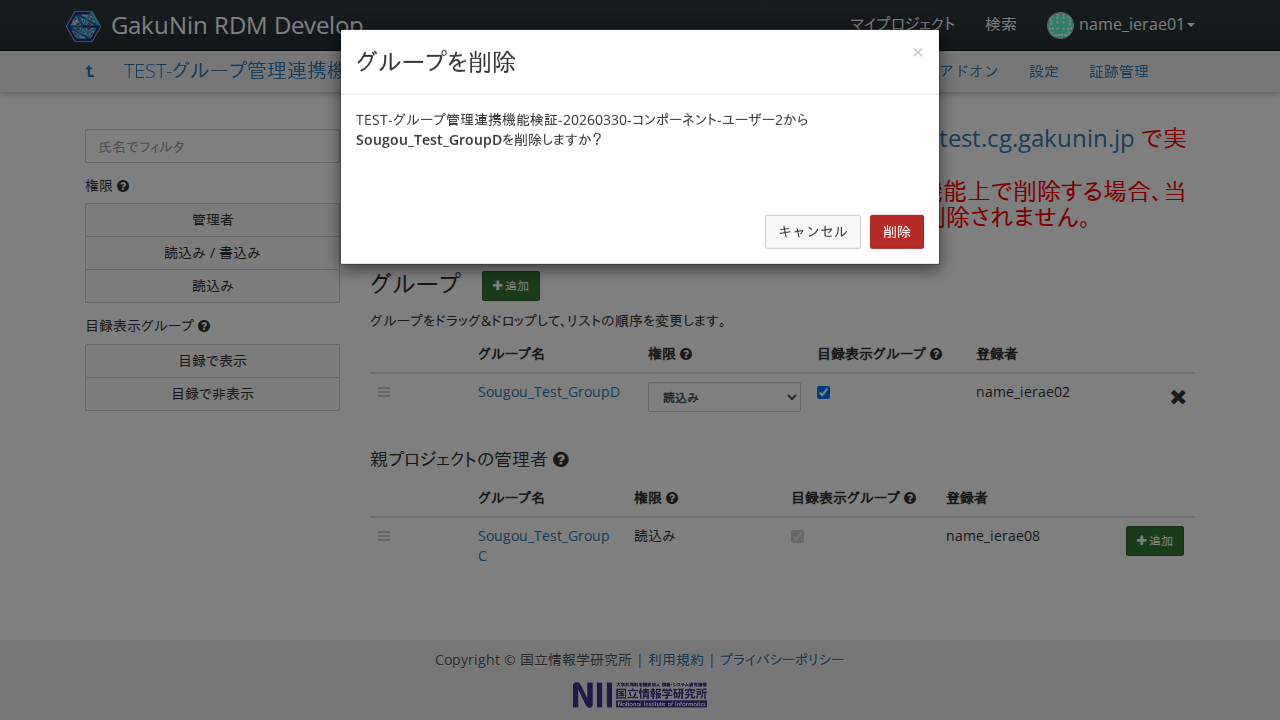

In [18]:
async def _step(page):
    
    # Identify group D
    group_row = page.locator("#groups tr").filter(has=page.get_by_text(group_D, exact=True))
    
    # Click the "remove (×)" button
    remove_button = group_row.locator("td.add-remove i.remove-or-reject")
    time.sleep(1)
    await remove_button.click() 
    await expect(page.locator("h3.modal-title", has_text="グループを削除")).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「グループを削除」ダイアログの「削除」ボタンをクリックする

- 「グループ」画面が表示されること
- 各グループに設定されているグループが存在しないこと

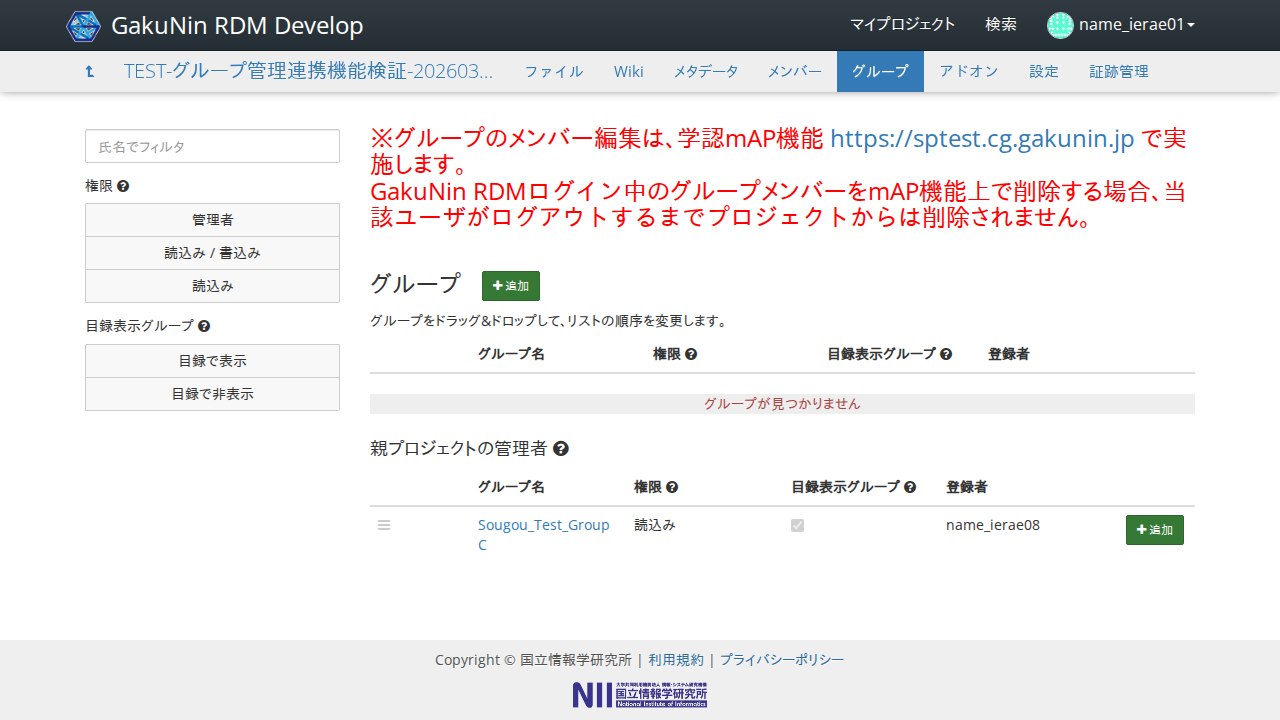

In [ ]:
async def _step(page):

    # Ensure modal exists
    delete_modal = page.locator("div.modal-content.scripted", has=page.locator("h3.modal-title", has_text="グループを削除"))
    await expect(delete_modal).to_be_attached()

    # Click 削除 button
    delete_button = delete_modal.locator("div.remove-page-buttons a.btn.btn-danger")
    await delete_button.click()

    # Wait until modal is removed
    await expect(delete_modal).not_to_be_attached()
    
    # グループ screen is displayed
    await expect(page.get_by_role("heading", name=group_note_text)).to_be_visible(timeout=transition_timeout)
    
    # There are no groups
    no_groups_message = page.locator("div.no-items.text-danger.m-b-md", has_text="グループが見つかりません")
    await expect(no_groups_message).to_be_visible(timeout=transition_timeout)
        
await run_pw(_step)

## "以下の手順を実施し、コンポーネントを削除する
- コンポーネントのプロジェクトダッシュボードの上部メニューから「設定」をクリックする
- 「コンポーネントを削除」を選択する
- 「次の文字列を入力して続行します」に記載されている文字列を入力欄に記載し、「削除」をクリックする
- 以下を確認すること
    - 設定画面が表示されること
    - 「このコンポーネントを削除してもよろしいですか？」のダイアログが表示されること
    - プロジェクトダッシュボードの「コンポーネント」から該当コンポーネントが消えること

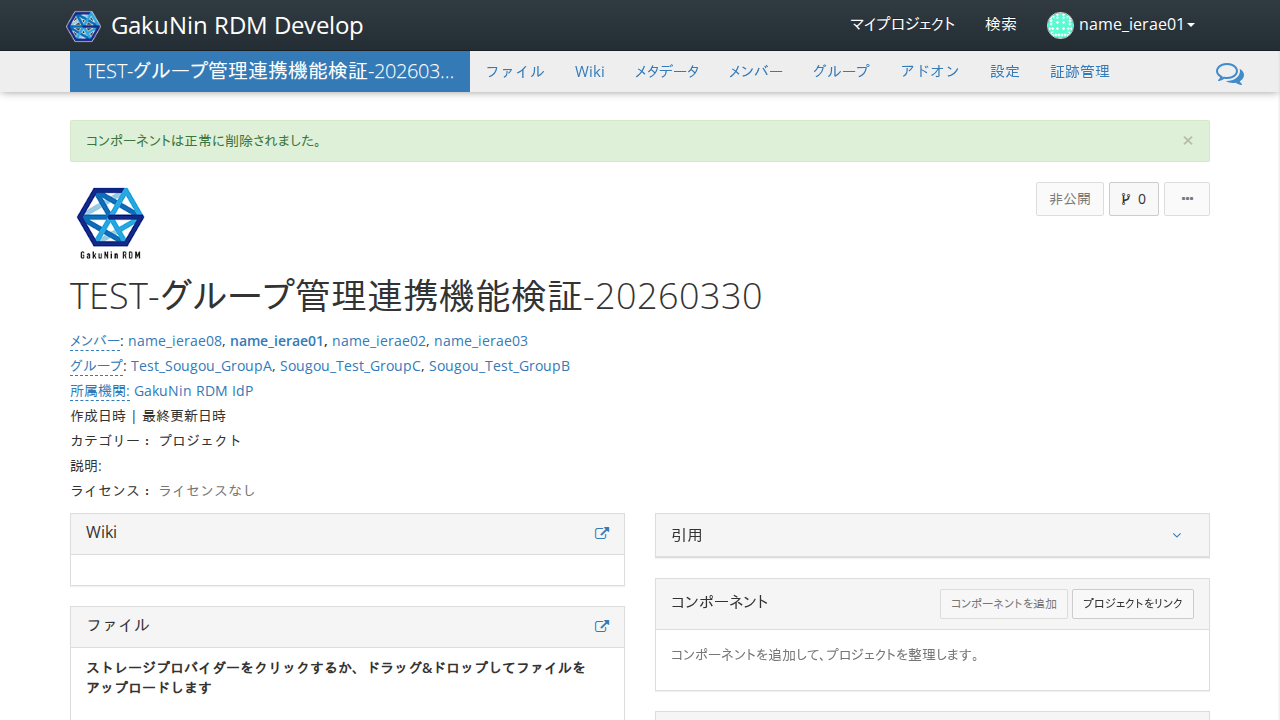

In [ ]:
async def _step(page):

    # Open 設定 screen
    await page.get_by_role("link", name="設定").click()
    
    # 設定 screen is displayed
    await expect(page.get_by_role("button", name="コンポーネントを削除")).to_be_visible(timeout=transition_timeout)

    # Click "コンポーネントを削除" button
    await page.get_by_role("button", name="コンポーネントを削除").click()

     # Wait for delete confirmation modal
    delete_modal = page.locator('#nodesDelete')
    await expect(delete_modal).to_be_visible(timeout=transition_timeout)

    await expect(delete_modal.locator('h3.modal-title')).to_have_text("このコンポーネントを削除してもよろしいですか？", timeout=transition_timeout)

    confirmation_label = page.locator('//strong[@data-bind = "text: confirmationString"]')
    await expect(confirmation_label).to_have_count(1, timeout=transition_timeout)
    confirmation = await confirmation_label.text_content()
    print(confirmation)

    time.sleep(1)
    confirmation_input = page.locator('//*[@data-bind = "editableHTML: {observable: confirmInput, onUpdate: handleEditableUpdate}"]')
    await confirmation_input.fill(confirmation)

    delete_button = page.locator('//a[contains(@class, "btn-danger") and text() = "削除"]')
    await expect(delete_button).to_be_visible()
    await delete_button.click()

    # Project dashboard is displayed
    await expect(page.locator('//a[text()="アドオン"]')).to_be_visible(timeout=transition_timeout)

    # Deleted component is not displayed
    await expect(page.locator('a', has_text=component_title)).to_have_count(0, timeout=transition_timeout)
    
await run_pw(_step)

## プロジェクトダッシュボードの上部メニューから「グループ」をクリックする

- 「グループ」画面が表示されること
- 各グループが以下の通りとなっていること。
    - 既存ユーザー2 が所属するグループ(グループA): 読込み/書込み
    - 既存ユーザー3 が所属するグループ(グループB): 読込み
    - 既存ユーザー4 が所属するグループ(グループC): 管理者
    - ~~既存ユーザー5 が所属するグループ(グループD): 読込み~~

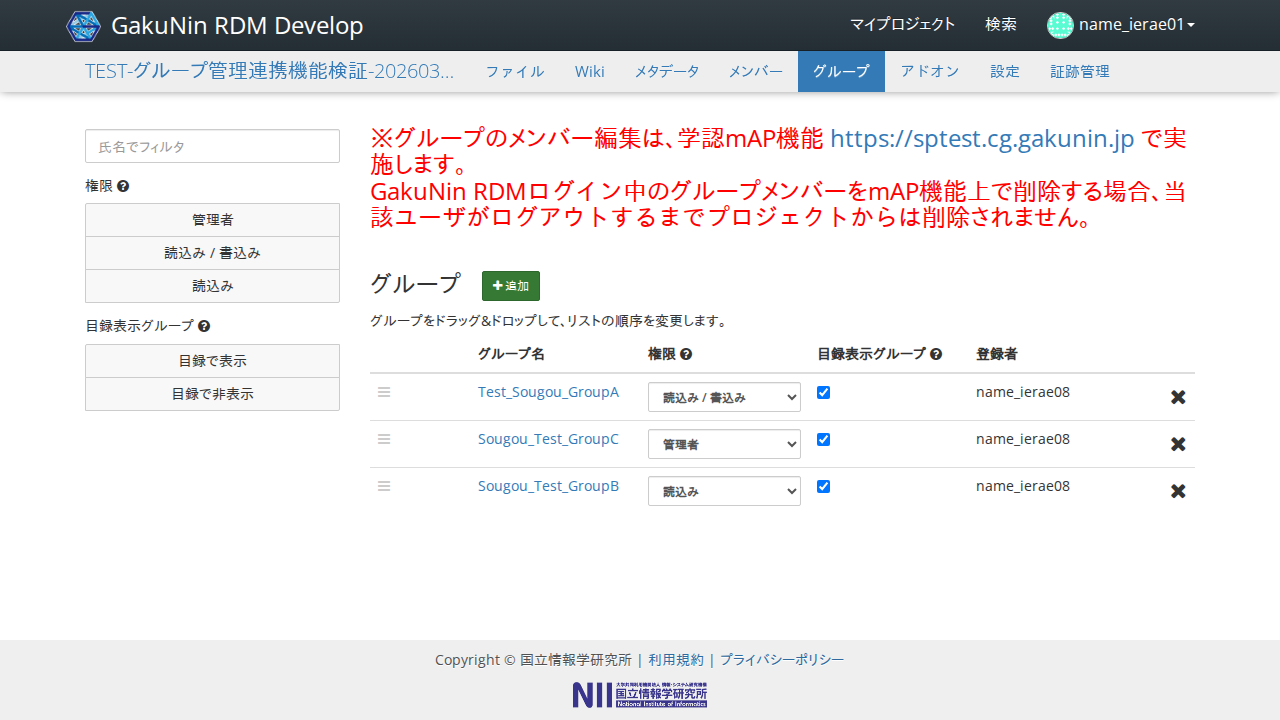

In [ ]:
async def _step(page):
    
    # Access グループ screen
    await page.locator("#projectSubnav").get_by_role("link", name="グループ", exact=True).click()

    # グループ screen is displayed
    await expect(page.get_by_role("heading", name=group_note_text)).to_be_visible(timeout=transition_timeout)

    # Groups permission
    Groups = {group_A: "読込み / 書込み", group_B: "読込み", group_C: "管理者"}

    groups_tbody = page.locator("#groups")

    for group_name, expected_permission in Groups.items():
        row = groups_tbody.locator("tr").filter(has=page.get_by_text(group_name, exact=True))
        await expect(row).to_have_count(1)
        permission = row.locator(".permission-filter")
        await expect(permission).to_have_text(expected_permission)

await run_pw(_step)

## 「名前」項目の既存ユーザー2が所属するグループ(グループA)の列の右端の「×」ボタンをクリックする

- 「グループを削除」ダイアログが表示されること

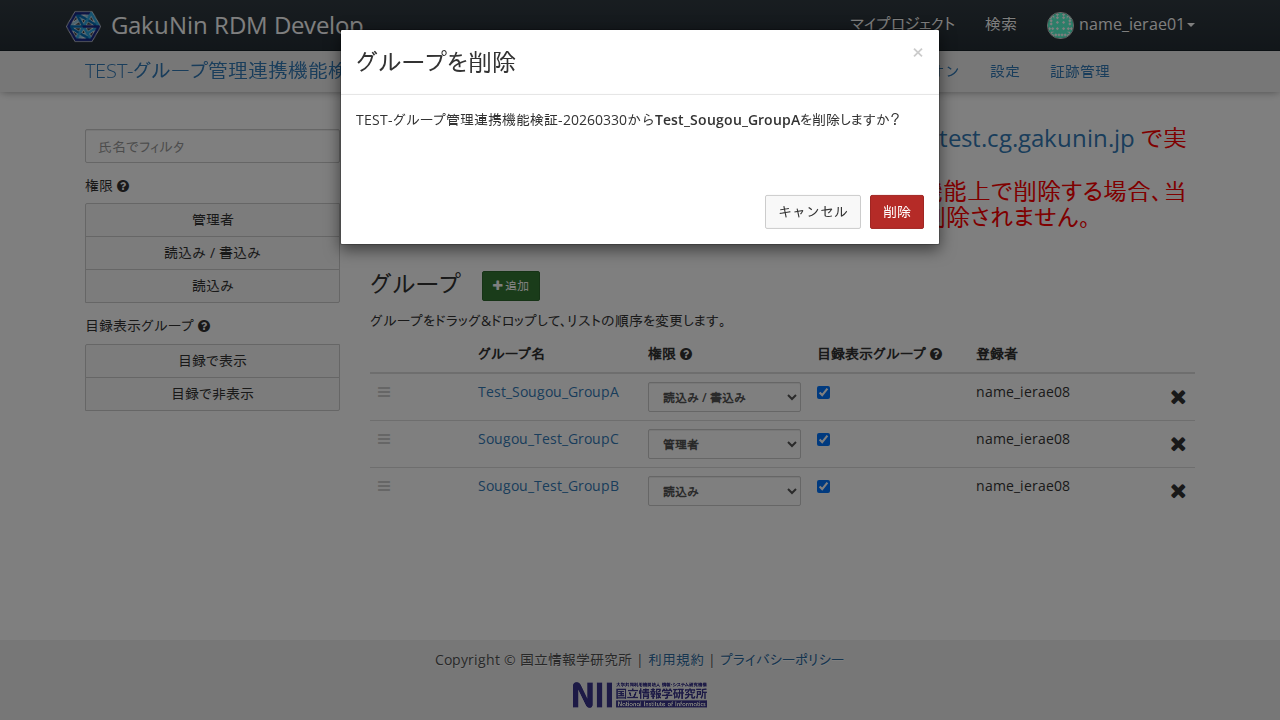

In [23]:
async def _step(page):
    
    # Identify group A
    group_row = page.locator("#groups tr").filter(has=page.get_by_text(group_A, exact=True))
    
    # Click the "remove (×)" button
    remove_button = group_row.locator("td.add-remove i.remove-or-reject")
    time.sleep(1)
    await remove_button.click() 
    await expect(page.locator("h3.modal-title", has_text="グループを削除")).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「グループを削除」ダイアログの「削除」ボタンをクリックする

- 「グループ」画面が表示されること
- 各グループが以下の通りとなっていること。
    - 既存ユーザー3 が所属するグループ(グループB): 読込み
    - 既存ユーザー4 が所属するグループ(グループC): 管理者
    - ~~既存ユーザー5 が所属するグループ(グループD): 読込み~~

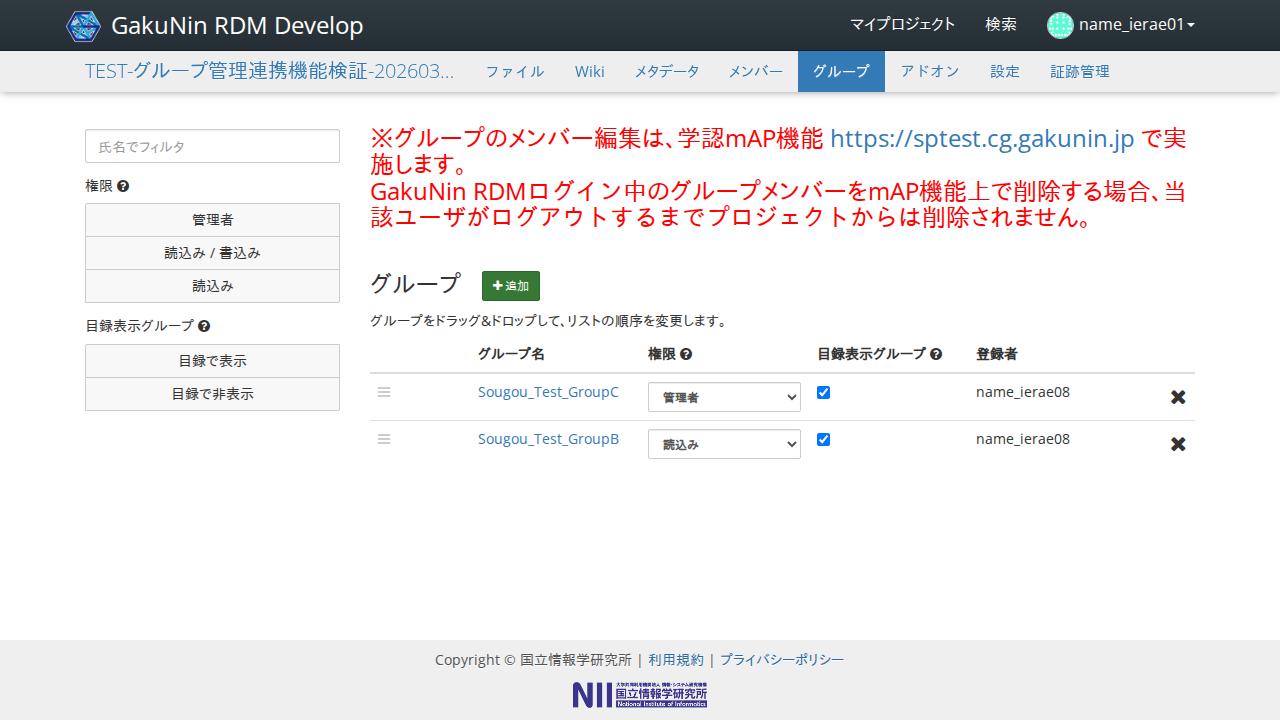

In [ ]:
async def _step(page):

     # Ensure modal exists
    delete_modal = page.locator("div.modal-content.scripted", has=page.locator("h3.modal-title", has_text="グループを削除"))
    await expect(delete_modal).to_be_attached()

    # Click 削除 button
    delete_button = delete_modal.locator("div.remove-page-buttons a.btn.btn-danger")
    await delete_button.click()

    # Wait until modal is removed
    await expect(delete_modal).not_to_be_attached()
    
    # グループ screen is displayed
    await expect(page.get_by_role("heading", name=group_note_text)).to_be_visible(timeout=transition_timeout)
    
    # Groups are displayed
    groups = [(group_B, "読込み"),(group_C, "管理者"),]
    for group_name, permission in groups:
        group_row = page.locator("#manageGroupsTable tbody tr.contrib", has=page.locator("a.name-search", has_text=group_name))
        await expect(group_row).to_be_visible()
        # Permission
        permission_locator = group_row.locator(".permission-filter") 
        await expect(permission_locator).to_have_text(permission)

await run_pw(_step)

## 「名前」項目の既存ユーザー3が所属するグループ(グループB)の列の右端の「×」ボタンをクリックする

- 「グループを削除」ダイアログが表示されること

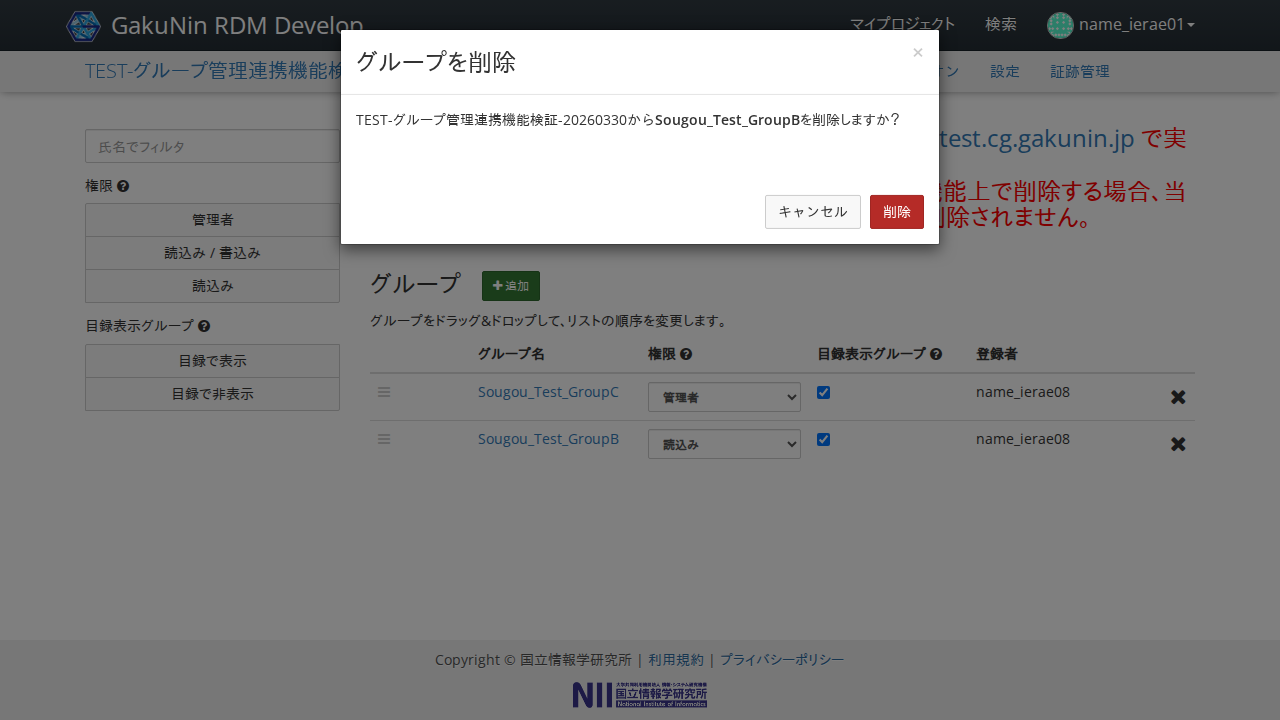

In [25]:
async def _step(page):
    
    # Identify group B
    group_row = page.locator("#groups tr").filter(has=page.get_by_text(group_B, exact=True))
    
    # Click the "remove (×)" button
    remove_button = group_row.locator("td.add-remove i.remove-or-reject")
    time.sleep(1)
    await remove_button.click() 
    await expect(page.locator("h3.modal-title", has_text="グループを削除")).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「グループを削除」ダイアログの「削除」ボタンをクリックする

- 「グループ」画面が表示されること
- 各グループが以下の通りとなっていること。
    - 既存ユーザー4 が所属するグループ(グループC): 管理者
    - ~~既存ユーザー5 が所属するグループ(グループD): 読込み~~

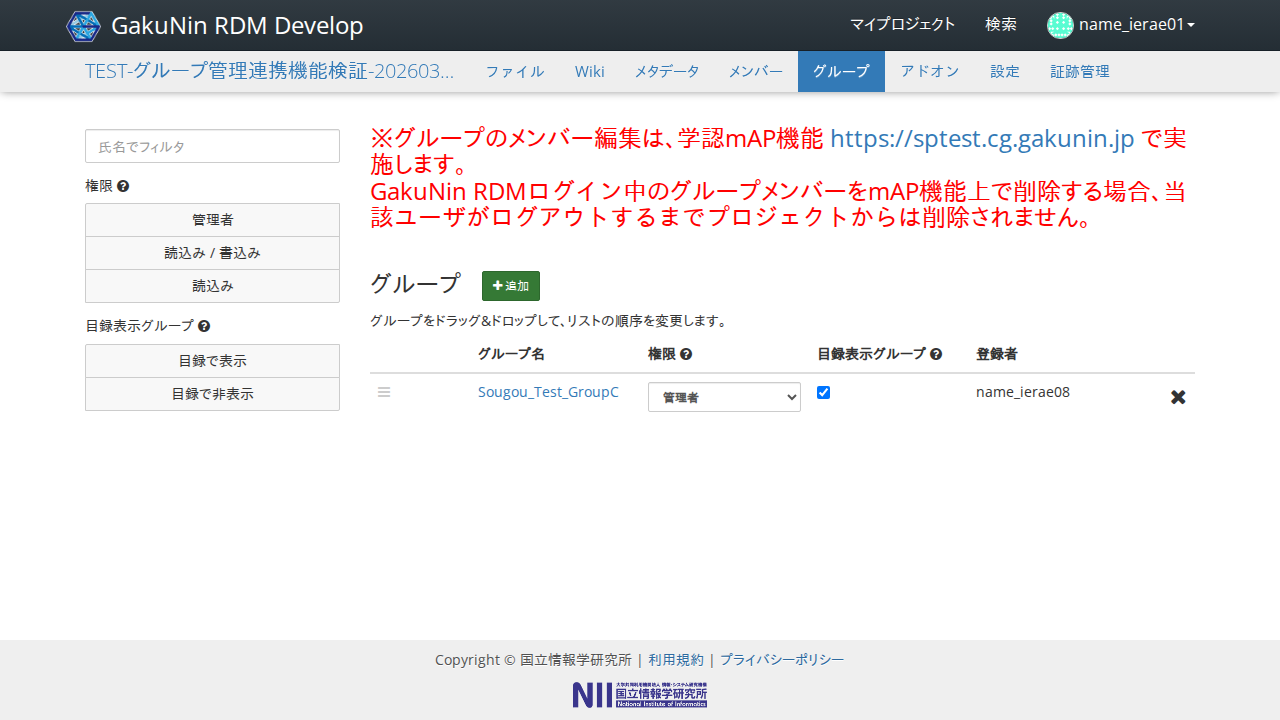

In [ ]:
async def _step(page):

    # Ensure modal exists
    delete_modal = page.locator("div.modal-content.scripted", has=page.locator("h3.modal-title", has_text="グループを削除"))
    await expect(delete_modal).to_be_attached()

    # Click 削除 button
    delete_button = delete_modal.locator("div.remove-page-buttons a.btn.btn-danger")
    await delete_button.click()

    # Wait until modal is removed
    await expect(delete_modal).not_to_be_attached()
    
    # グループ screen is displayed
    await expect(page.get_by_role("heading", name=group_note_text)).to_be_visible(timeout=transition_timeout)
    
    # Groups are displayed
    groups = [(group_C, "管理者")]
    for group_name, permission in groups:
        group_row = page.locator("#manageGroupsTable tbody tr.contrib", has=page.locator("a.name-search", has_text=group_name))
        await expect(group_row).to_be_visible()
        # Permission
        permission_locator = group_row.locator(".permission-filter") 
        await expect(permission_locator).to_have_text(permission)
        
await run_pw(_step)

## 「名前」項目の既存ユーザー4が所属するグループ(グループC)の列の右端の「×」ボタンをクリックする

- 「グループを削除」ダイアログが表示されること

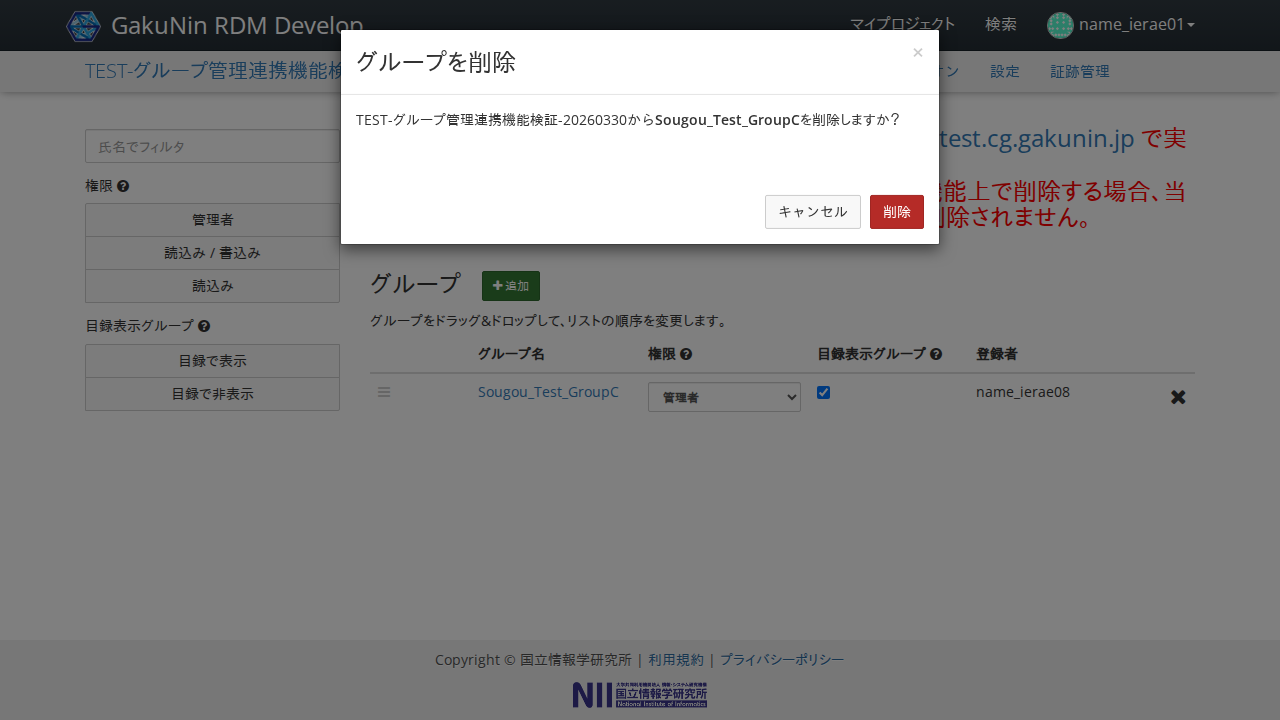

In [27]:
async def _step(page):
    
    # Identify group C
    group_row = page.locator("#groups tr").filter(has=page.get_by_text(group_C, exact=True))
    
    # Click the "remove (×)" button
    remove_button = group_row.locator("td.add-remove i.remove-or-reject")
    time.sleep(1)
    await remove_button.click() 
    await expect(page.locator("h3.modal-title", has_text="グループを削除")).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「グループを削除」ダイアログの「削除」ボタンをクリックする

- 「グループ」画面が表示されること
- 各グループが以下の通りとなっていること。
    - ~~既存ユーザー5 が所属するグループ(グループD): 読込み~~

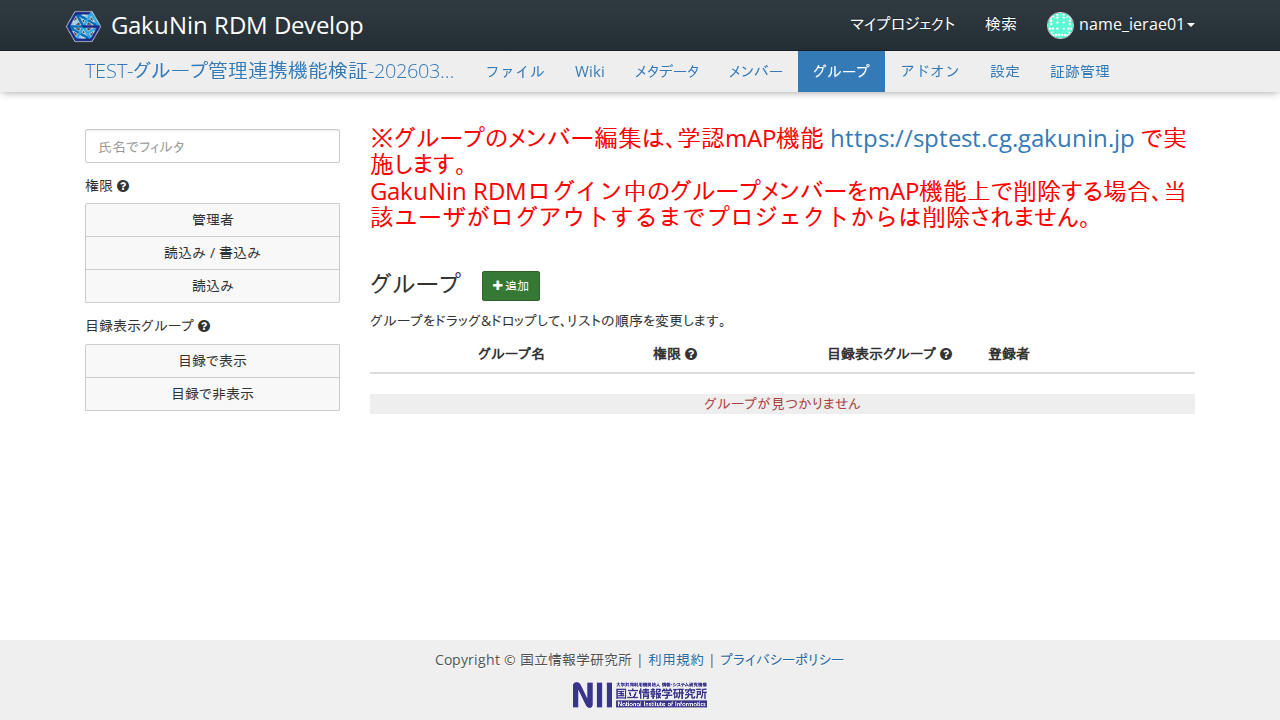

In [ ]:
async def _step(page):

    # Ensure modal exists
    delete_modal = page.locator("div.modal-content.scripted", has=page.locator("h3.modal-title", has_text="グループを削除"))
    await expect(delete_modal).to_be_attached()

    # Click 削除 button
    delete_button = delete_modal.locator("div.remove-page-buttons a.btn.btn-danger")
    await delete_button.click()

    # Wait until modal is removed
    await expect(delete_modal).not_to_be_attached()
    
    # グループ screen is displayed
    await expect(page.get_by_role("heading", name=group_note_text)).to_be_visible(timeout=transition_timeout)
    
    # # Groups are displayed
    # groups = [(group_D, "読込み"),]
    # for group_name, permission in groups:
    #     group_row = page.locator("#manageGroupsTable tbody tr.contrib", has=page.locator("a.name-search", has_text=group_name))
    #     await expect(group_row).to_be_visible()
    #     # Permission
    #     permission_locator = group_row.locator(".permission-filter") 
    #     await expect(permission_locator).to_have_text(permission)
        
await run_pw(_step)

## 「名前」項目の既存ユーザー5が所属するグループ(グループD)の列の右端の「×」ボタンをクリックする

- 「グループを削除」ダイアログが表示されること

In [ ]:
# async def _step(page):
    
#     # Identify group D
#     group_row = page.locator("#groups tr").filter(has=page.get_by_text(group_D, exact=True))
    
#     # Click the "remove (×)" button
#     remove_button = group_row.locator("td.add-remove i.remove-or-reject") 
#     await remove_button.click() 
#     await expect(page.locator("h3.modal-title", has_text="グループを削除")).to_be_visible(timeout=transition_timeout)

# await run_pw(_step)

## 「グループを削除」ダイアログの「削除」ボタンをクリックする

- 「グループ」画面が表示されること
- 各グループに設定されているグループが存在しないこと

In [ ]:
# async def _step(page):

#     # Ensure modal exists
#     delete_modal = page.locator("div.modal-content.scripted", has=page.locator("h3.modal-title", has_text="グループを削除"))
#     await expect(delete_modal).to_be_attached()

#     # Click 削除 button
#     delete_button = delete_modal.locator("div.remove-page-buttons a.btn.btn-danger")
#     await delete_button.click()

#     # Wait until modal is removed
#     await expect(delete_modal).not_to_be_attached()
    
#     # グループ screen is displayed
#     await expect(page.locator("h3", has_text="グループ")).to_be_visible(timeout=transition_timeout)
    
#     # There are no groups
#     no_groups_message = page.locator("div.no-items.text-danger.m-b-md", has_text="グループが見つかりません")
#     await expect(no_groups_message).to_be_visible(timeout=transition_timeout)
        
# await run_pw(_step)

## プロジェクトダッシュボードの上部メニューから「アドオン」をクリックする

- アドオン設定画面が表示されること

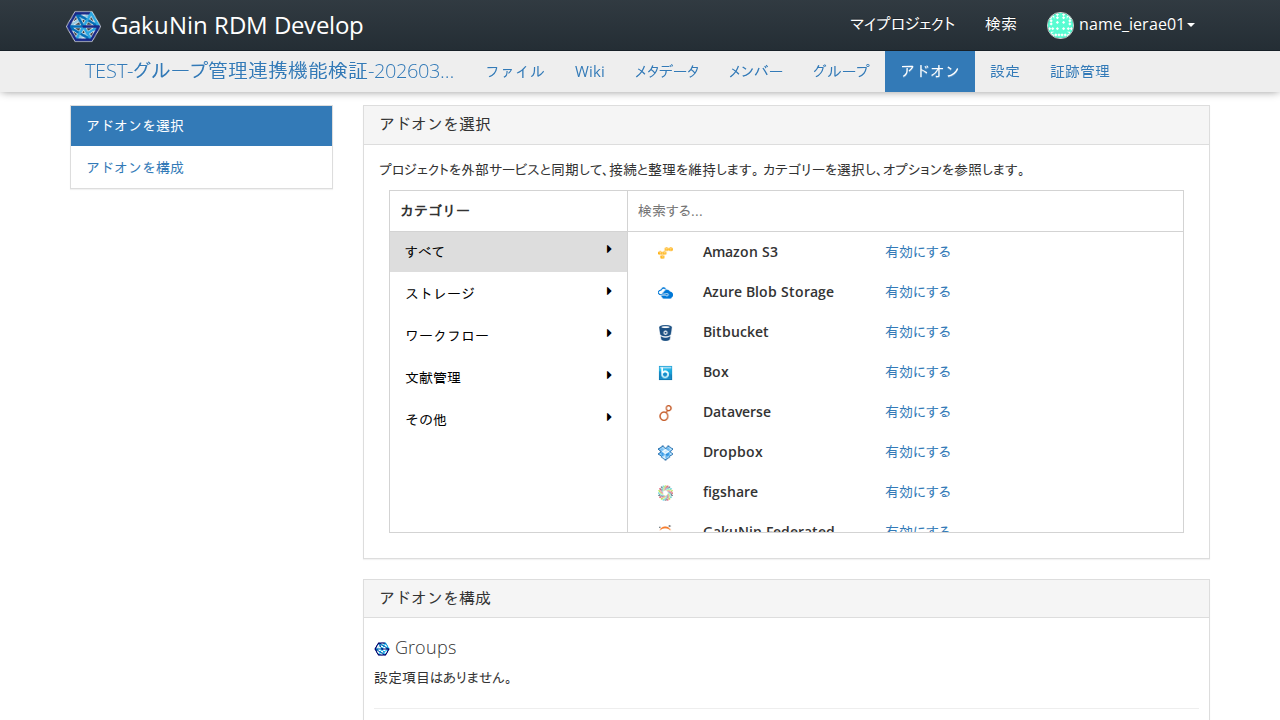

In [29]:
async def _step(page):
    await page.locator("#projectSubnav").get_by_role("link", name="アドオン").click()
    await expect(page.get_by_role("heading", name="アドオンを選択", level=3)).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「アドオンを選択」のパネル内「Groups」の行の「無効にする」をクリックする。

・「アドオンを無効にしますか？」のダイアログが表示されること

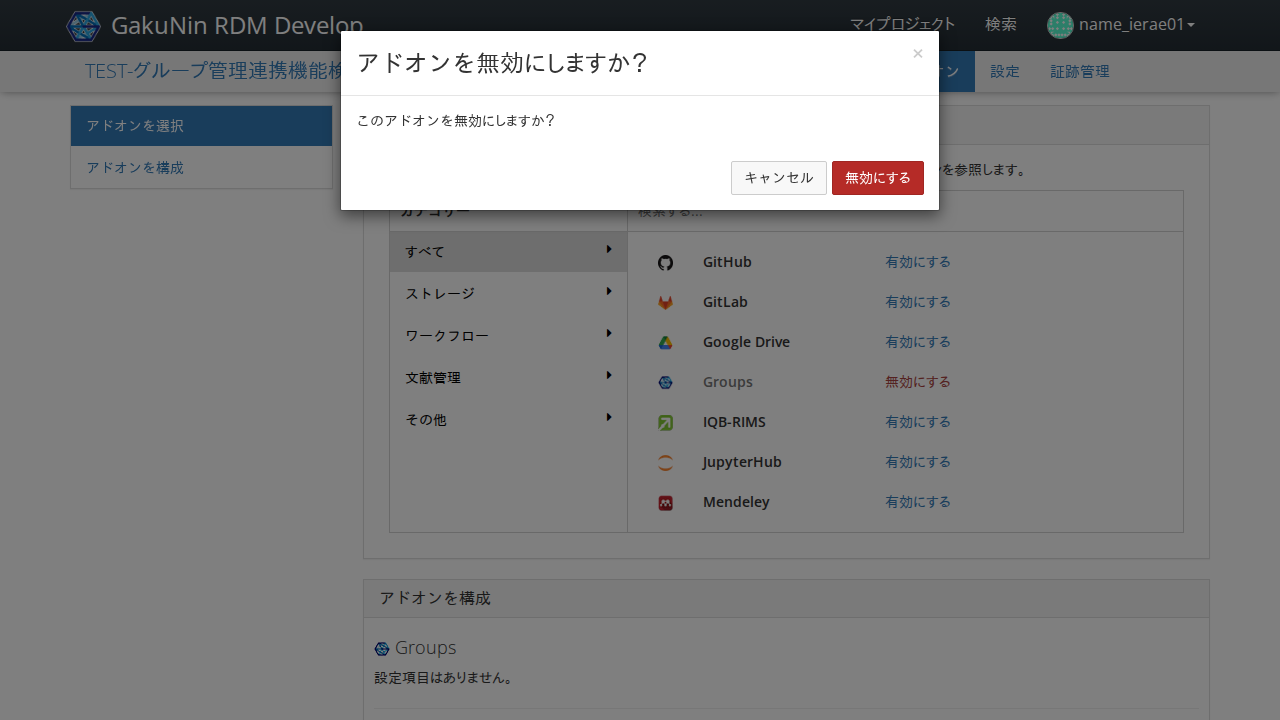

In [30]:
async def _step(page):
    enable_button = page.locator('div.addon-container[name="groups"] a', has_text="無効にする")
    await enable_button.scroll_into_view_if_needed()
    await enable_button.click()
    await expect(page.get_by_role("heading", name="アドオンを無効にしますか？")).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「アドオンを無効にしますか？」のダイアログで「無効にする」をクリックする

- 「アドオンを構成」のパネル内に「Groups」の行が消えること
- プロジェクトダッシュボードの上部メニューから「グループ」が消えること

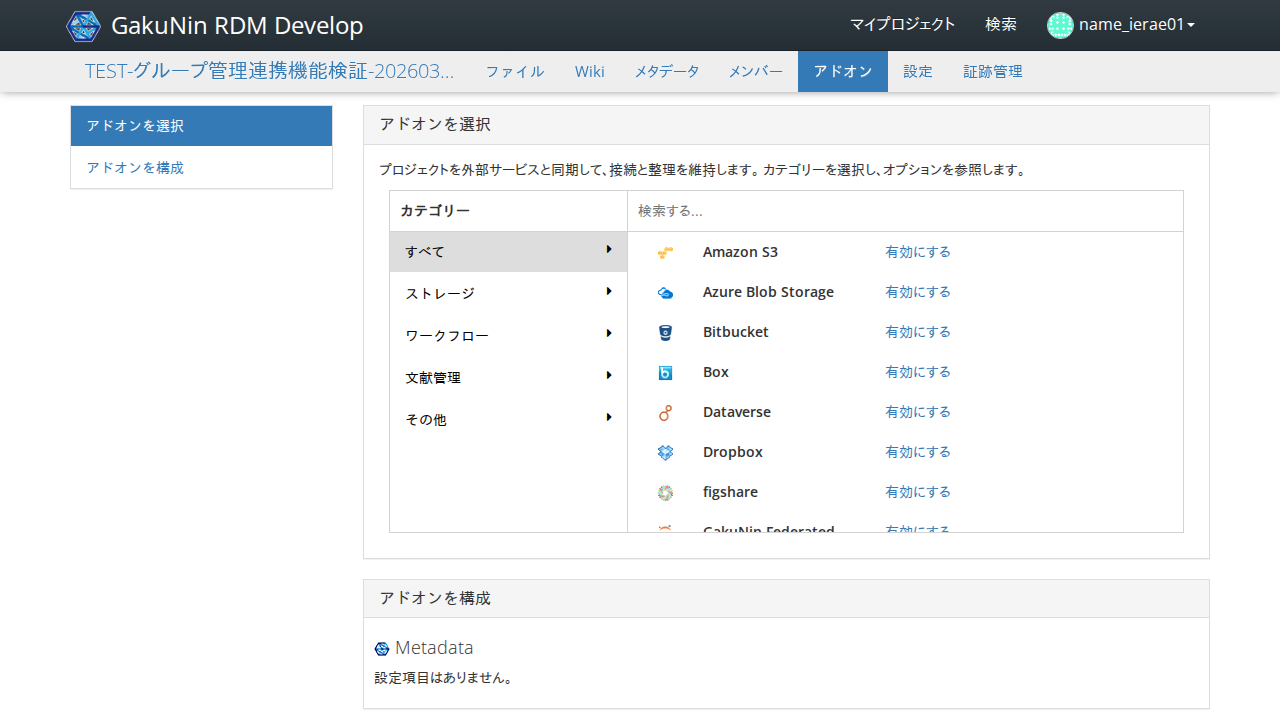

In [31]:
async def _step(page):
    # Locate and click the "確認" button
    confirm_button = page.locator('button[data-bb-handler="confirm"]', has_text="無効にする")
    await confirm_button.click()
    await expect(page.locator('div#groupsScope.scripted')).not_to_be_visible(timeout=transition_timeout)
    await expect(page.locator("#projectSubnav").get_by_role("link", name="グループ", exact=True)).not_to_be_visible(timeout=transition_timeout)
await run_pw(_step)

## 以下の手順を実施し、プロジェクトを削除する
- プロジェクトダッシュボードの上部メニューから「設定」をクリックする
- 「プロジェクトを削除」を選択する
- 「次の文字列を入力して続行します」に記載されている文字列を入力欄に記載し、「削除」をクリックする
- 以下を確認すること
    - 設定画面が表示されること
    - 「このプロジェクトを削除してもよろしいですか？」のダイアログが表示されること
    - ダッシュボードのプロジェクト一覧から該当プロジェクトが消えること"

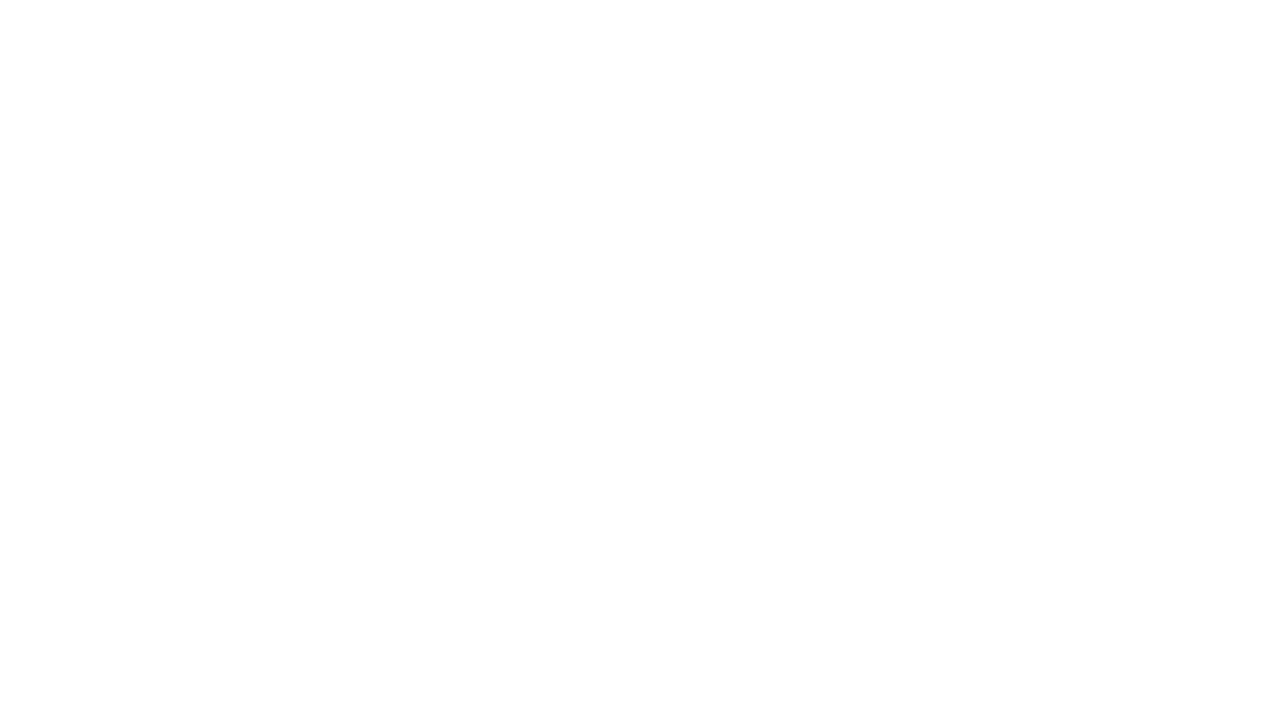

In [ ]:
async def _step(page):

    # Open 設定 screen
    await page.get_by_role("link", name="設定").click()
    
    # 設定 screen is displayed
    await expect(page.get_by_text("プロジェクトを削除", exact=True)).to_be_visible(timeout=transition_timeout)

    # Click "コンポーネントを削除" button
    await page.get_by_role("button", name="プロジェクトを削除").click()

     # Wait for delete confirmation modal
    delete_modal = page.locator('#nodesDelete')
    await expect(delete_modal).to_be_visible(timeout=transition_timeout)

    await expect(delete_modal.locator('h3.modal-title')).to_have_text("このプロジェクトを削除してもよろしいですか？", timeout=transition_timeout)

    confirmation_label = page.locator('//strong[@data-bind = "text: confirmationString"]')
    await expect(confirmation_label).to_have_count(1, timeout=transition_timeout)
    confirmation = await confirmation_label.text_content()
    print(confirmation)

    time.sleep(1)
    confirmation_input = page.locator('//*[@data-bind = "editableHTML: {observable: confirmInput, onUpdate: handleEditableUpdate}"]')
    await confirmation_input.fill(confirmation)

    delete_button = page.locator('//a[contains(@class, "btn-danger") and text() = "削除"]')
    await expect(delete_button).to_be_visible()
    await delete_button.click()

    # Dashboard screen is displayed
    time.sleep(1)
    deleted_project = page.locator('[data-test-dashboard-item-title]',has_text=rdm_project_name)
    await expect(deleted_project).to_have_count(0, timeout=transition_timeout)
    time.sleep(1)

await run_pw(_step)

終了処理を実施。

In [ ]:
await finish_pw_context()

In [ ]:
!rm -fr {work_dir}